# Projeto de Parceria Semantix — Análise Exploratória de Dados em E-commerce

Este notebook faz a análise exploratória do arquivo `ecommerce_estatistica.csv`, utilizado no projeto de parceria Semantix.

## Objetivo do projeto

Investigar quais fatores podem influenciar a quantidade vendida de produtos em um e-commerce, considerando variáveis como preço, desconto, nota, número de avaliações, marca, material, gênero e temporada.

## Pergunta principal

**Como identificar os fatores que mais influenciam as vendas de produtos em um e-commerce?**

## 1. Importação das bibliotecas

Nesta etapa, importamos as bibliotecas necessárias para leitura, tratamento, análise e visualização dos dados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import unicodedata
import re

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Pastas de saída para os arquivos do projeto
Path('resultados').mkdir(exist_ok=True)
Path('imagens').mkdir(exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## 2. Leitura da base de dados

O código abaixo procura automaticamente o arquivo CSV na mesma pasta do notebook.

Ele aceita os nomes:

- `ecommerce_estatistica.csv`
- `ecommerce_estatistica(2).csv`

In [2]:
possiveis_arquivos = [
    Path('ecommerce_estatistica.csv'),
    Path('ecommerce_estatistica(2).csv'),
    Path('/mnt/data/ecommerce_estatistica.csv'),
    Path('/mnt/data/ecommerce_estatistica(2).csv')
]

arquivo_csv = next((arquivo for arquivo in possiveis_arquivos if arquivo.exists()), None)

if arquivo_csv is None:
    raise FileNotFoundError('Arquivo CSV não encontrado. Coloque o arquivo ecommerce_estatistica.csv na mesma pasta do notebook.')

print(f'Arquivo utilizado: {arquivo_csv}')

df_original = pd.read_csv(arquivo_csv)
df = df_original.copy()

print(f'Quantidade de linhas: {df.shape[0]}')
print(f'Quantidade de colunas: {df.shape[1]}')

df.head()

Arquivo utilizado: ecommerce_estatistica(2).csv
Quantidade de linhas: 295
Quantidade de colunas: 24


,Unnamed: 0,Título,Nota,N_Avaliações,Desconto,Marca,Material,Gênero,Temporada,Review1,Review2,Review3,Qtd_Vendidos,Preço,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,"Pelo preço promocional, com ctz tem algum defe...","Serviram muito bem, porém é nítido que o pano ...",+10mil,232.89,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
1,2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,Vendo comentários de outros consumidores vejo ...,"Produto não é nem de longe original, tecido gr...",+50mil,199.90,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
2,3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...","E o tamanho certo, mas em baixo dela, fica mui...",Produto não parece.\nOriginal e veio 2 modelos...,+10mil,229.39,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444
3,4,Kit 3 Short Jeans Feminino Cintura Alta Barato...,4.4,507.0,9.0,menina linda,jean,Feminino,primavera/verão,Estou encantada com essas peças!.\nOs shorts s...,"Recomendo, tecido confortável, igual a foto.","Gostei muito dos shorts, material bom, para us...",+1000,129.20,0.777778,0.055751,0.065574,0.201767,509,74,7,1000.0,0.010005,0.025466
4,5,Blusa + Calça Térmica Treino Futebol Criança I...,4.7,58.0,5.0,roupa zero grau,termico unissex,Sem gênero infantil,outono/inverno,"Produto ótimo , mesmo após várias lavagens não...",Produto de boa qualidade.\nNão gruda pêlos e n...,Super quentinho. Só achei a gola muito aberta.,+100,78.03,0.888889,0.006280,0.000000,0.114508,669,166,3,100.0,0.002274,0.000910


## 3. Exploração inicial

Nesta etapa, analisamos a estrutura da base, os tipos de dados, as colunas disponíveis, valores nulos e possíveis duplicidades.

In [3]:
# Visualizando as colunas originais
list(df.columns)

['Unnamed: 0',
 'Título',
 'Nota',
 'N_Avaliações',
 'Desconto',
 'Marca',
 'Material',
 'Gênero',
 'Temporada',
 'Review1',
 'Review2',
 'Review3',
 'Qtd_Vendidos',
 'Preço',
 'Nota_MinMax',
 'N_Avaliações_MinMax',
 'Desconto_MinMax',
 'Preço_MinMax',
 'Marca_Cod',
 'Material_Cod',
 'Temporada_Cod',
 'Qtd_Vendidos_Cod',
 'Marca_Freq',
 'Material_Freq']

In [4]:
# Tipos de dados e quantidade de registros preenchidos
info_df = pd.DataFrame({
    'coluna': df.columns,
    'tipo': df.dtypes.astype(str).values,
    'valores_nao_nulos': df.notna().sum().values,
    'valores_nulos': df.isna().sum().values,
    'percentual_nulos': (df.isna().mean().values * 100).round(2)
})

info_df

,coluna,tipo,valores_nao_nulos,valores_nulos,percentual_nulos
0,Unnamed: 0,int64,295,0,0.0
1,Título,object,295,0,0.0
2,Nota,float64,295,0,0.0
3,N_Avaliações,float64,295,0,0.0
4,Desconto,float64,295,0,0.0
5,Marca,object,295,0,0.0
6,Material,object,295,0,0.0
7,Gênero,object,295,0,0.0
8,Temporada,object,295,0,0.0
9,Review1,object,295,0,0.0


In [5]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,295.0,1003.084746,659.415936,1.000000,401.000000,969.000000,1581.500000,2198.000000
Nota,295.0,4.480678,0.321243,2.300000,4.300000,4.500000,4.700000,5.000000
N_Avaliações,295.0,490.511864,1079.395818,3.000000,19.000000,77.000000,326.000000,9077.000000
Desconto,295.0,16.013559,9.928305,5.000000,9.000000,11.000000,22.000000,51.000000
Preço,295.0,130.836644,64.232780,25.630000,73.340000,129.210000,179.900000,326.550000
Nota_MinMax,295.0,0.807659,0.118979,0.000000,0.740741,0.814815,0.888889,1.000000
N_Avaliações_MinMax,295.0,0.053935,0.118929,0.000220,0.001983,0.008374,0.035809,1.000000
Desconto_MinMax,295.0,0.180550,0.162759,0.000000,0.065574,0.098361,0.278689,0.754098
Preço_MinMax,295.0,0.204558,0.109534,0.025153,0.106511,0.201784,0.288223,0.538300
Marca_Cod,295.0,457.681356,240.374227,13.000000,263.000000,463.000000,692.000000,841.000000


In [6]:
# Verificação de duplicidades
print('Quantidade de linhas duplicadas:', df.duplicated().sum())

Quantidade de linhas duplicadas: 0


## 4. Limpeza e padronização dos dados

Nesta etapa, os nomes das colunas são padronizados para facilitar o uso no Python, no SQL e no Looker Studio.

Também são removidas colunas de índice desnecessárias, como `Unnamed: 0`, quando existirem.

In [7]:
def padronizar_nome_coluna(nome):
    """Remove acentos, espaços e caracteres especiais dos nomes das colunas."""
    nome = unicodedata.normalize('NFKD', str(nome)).encode('ascii', 'ignore').decode('utf-8')
    nome = nome.strip().lower()
    nome = re.sub(r'[^a-z0-9]+', '_', nome)
    nome = nome.strip('_')
    return nome

# Padronizando nomes das colunas
df.columns = [padronizar_nome_coluna(coluna) for coluna in df.columns]

# Removendo colunas de índice automático, se existirem
colunas_unnamed = [coluna for coluna in df.columns if coluna.startswith('unnamed')]
df = df.drop(columns=colunas_unnamed, errors='ignore')

print('Colunas após padronização:')
list(df.columns)

Colunas após padronização:


['titulo',
 'nota',
 'n_avaliacoes',
 'desconto',
 'marca',
 'material',
 'genero',
 'temporada',
 'review1',
 'review2',
 'review3',
 'qtd_vendidos',
 'preco',
 'nota_minmax',
 'n_avaliacoes_minmax',
 'desconto_minmax',
 'preco_minmax',
 'marca_cod',
 'material_cod',
 'temporada_cod',
 'qtd_vendidos_cod',
 'marca_freq',
 'material_freq']

In [8]:
# Tratamento de valores nulos, caso existam
colunas_numericas = df.select_dtypes(include='number').columns
colunas_texto = df.select_dtypes(exclude='number').columns

for coluna in colunas_numericas:
    df[coluna] = df[coluna].fillna(df[coluna].median())

for coluna in colunas_texto:
    df[coluna] = df[coluna].fillna('não informado')

# Removendo duplicidades, caso existam
df = df.drop_duplicates()

print('Base após tratamento:')
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')
print('\nValores nulos restantes:')
print(df.isna().sum().sum())

Base após tratamento:
Linhas: 238
Colunas: 23

Valores nulos restantes:
0


## 5. Métricas gerais da base

Aqui são calculados os principais indicadores que poderão ser usados no dashboard do Looker Studio.

In [9]:
metricas_gerais = pd.DataFrame({
    'Métrica': [
        'Total de produtos analisados',
        'Total de vendas codificadas',
        'Preço médio',
        'Desconto médio',
        'Nota média',
        'Total de avaliações'
    ],
    'Valor': [
        len(df),
        df['qtd_vendidos_cod'].sum(),
        df['preco'].mean(),
        df['desconto'].mean(),
        df['nota'].mean(),
        df['n_avaliacoes'].sum()
    ]
})

metricas_gerais

,Métrica,Valor
0,Total de produtos analisados,238.000000
1,Total de vendas codificadas,586435.000000
2,Preço médio,126.883193
3,Desconto médio,16.420168
4,Nota média,4.488235
5,Total de avaliações,92283.000000


## 6. Análise de distribuição dos preços

Esta análise ajuda a entender a faixa de preço predominante dos produtos presentes na base.

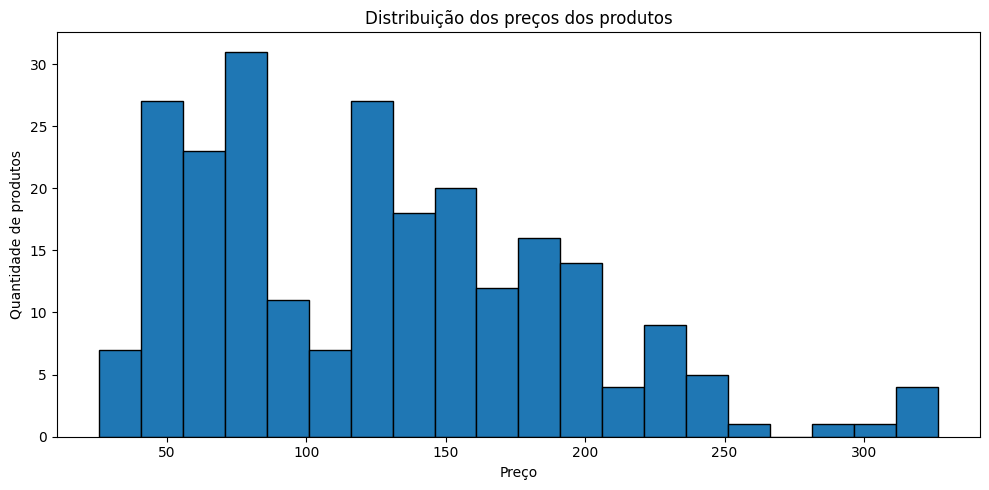

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df['preco'], bins=20, edgecolor='black')
plt.title('Distribuição dos preços dos produtos')
plt.xlabel('Preço')
plt.ylabel('Quantidade de produtos')
plt.tight_layout()
plt.savefig('imagens/histograma_precos.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Vendas por marca

Esta análise identifica quais marcas concentram maior quantidade vendida.

In [11]:
vendas_marca = (
    df.groupby('marca', as_index=False)['qtd_vendidos_cod']
    .sum()
    .sort_values('qtd_vendidos_cod', ascending=False)
)

vendas_marca.head(10)

,marca,qtd_vendidos_cod
106,zorba,163100.0
53,lupo,132150.0
65,moda llevo,50000.0
105,zaroc,50000.0
47,keeper,30350.0
60,mash,23100.0
4,almix,20000.0
94,stillger jeans,12800.0
66,moralice,10000.0
107,éved maromba malhar fitness machão,10000.0


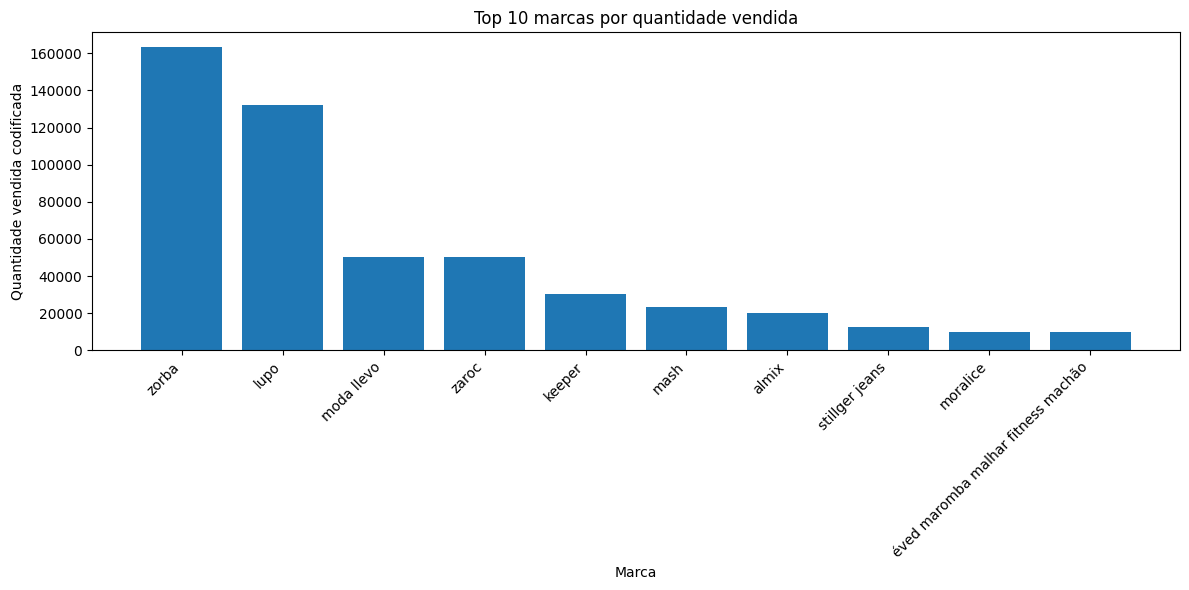

In [12]:
top_marcas = vendas_marca.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_marcas['marca'], top_marcas['qtd_vendidos_cod'])
plt.title('Top 10 marcas por quantidade vendida')
plt.xlabel('Marca')
plt.ylabel('Quantidade vendida codificada')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('imagens/grafico_vendas_marca.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Vendas por material

Esta análise permite identificar quais materiais aparecem associados a maior volume de vendas.

In [13]:
vendas_material = (
    df.groupby('material', as_index=False)['qtd_vendidos_cod']
    .sum()
    .sort_values('qtd_vendidos_cod', ascending=False)
)

vendas_material.head(10)

,material,qtd_vendidos_cod
3,algodão,340655.0
28,microfibra,54850.0
46,tecido suplex,51000.0
21,jean,33300.0
35,poliéster,21355.0
6,algodão cotton,20000.0
32,poliamida,13100.0
39,sarja,13000.0
48,tshirt atual estilosa slim barata,10000.0
13,brim algodão microfibra,10000.0


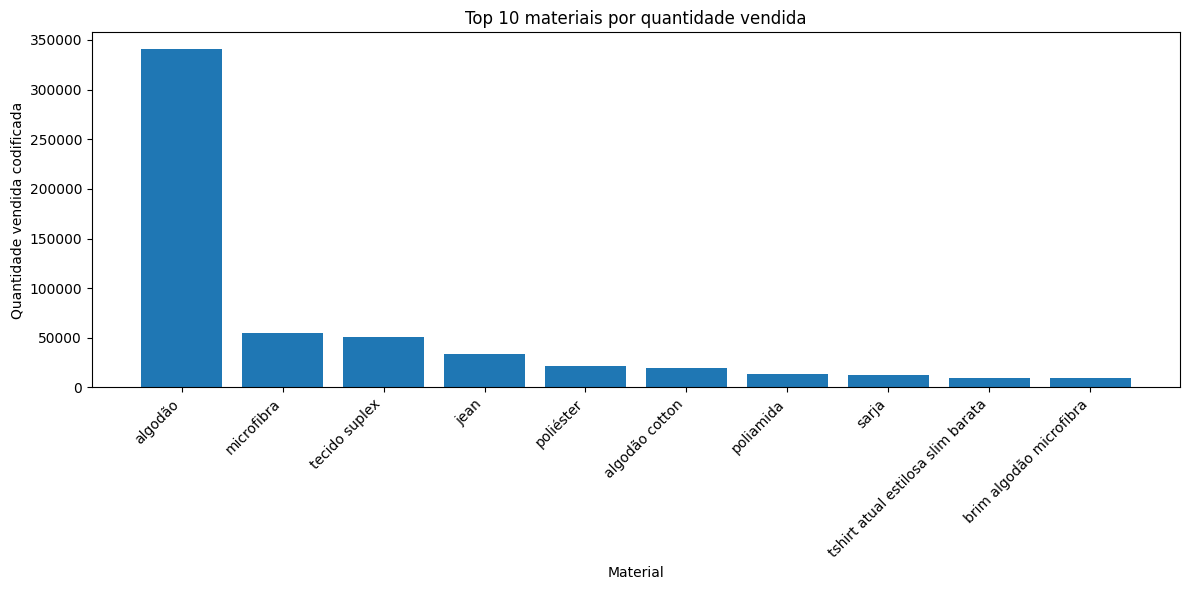

In [14]:
top_materiais = vendas_material.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_materiais['material'], top_materiais['qtd_vendidos_cod'])
plt.title('Top 10 materiais por quantidade vendida')
plt.xlabel('Material')
plt.ylabel('Quantidade vendida codificada')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('imagens/grafico_vendas_material.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Vendas por temporada

Esta análise ajuda a entender se há influência de sazonalidade no desempenho dos produtos.

In [15]:
vendas_temporada = (
    df.groupby('temporada', as_index=False)['qtd_vendidos_cod']
    .sum()
    .sort_values('qtd_vendidos_cod', ascending=False)
)

vendas_temporada

,temporada,qtd_vendidos_cod
1,não definido,274475.0
5,primavera/verão,192560.0
2,outono/inverno,82300.0
4,primavera-verão outono-inverno,24100.0
3,primavera-verão - outono-inverno,10000.0
0,2021,2000.0
6,primavera/verão/outono/inverno,1000.0


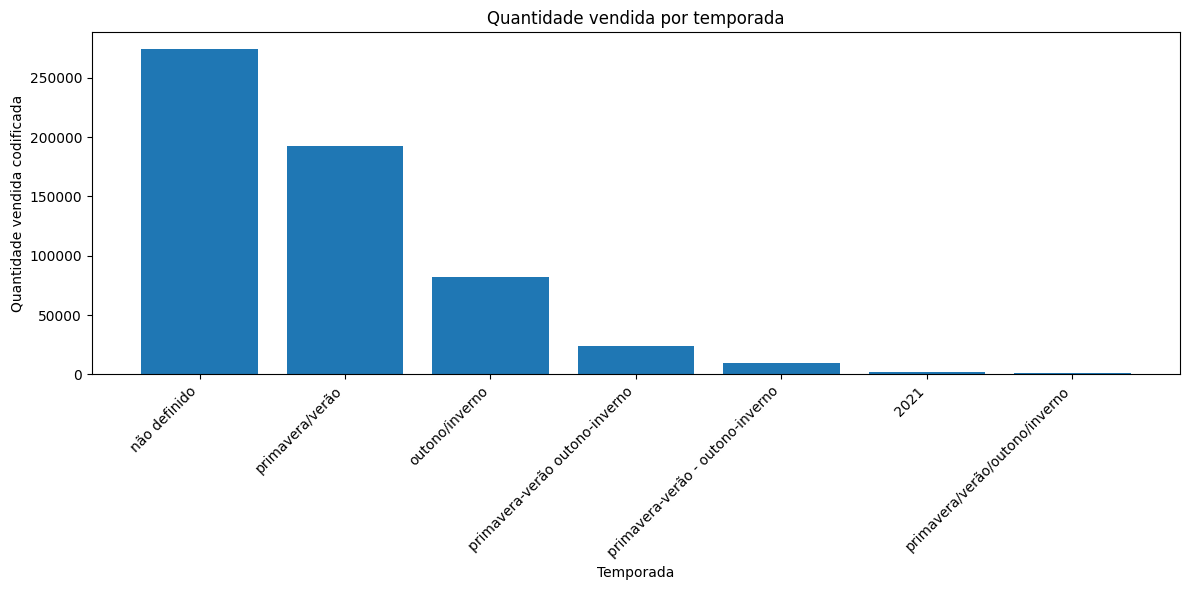

In [16]:
plt.figure(figsize=(12, 6))
plt.bar(vendas_temporada['temporada'], vendas_temporada['qtd_vendidos_cod'])
plt.title('Quantidade vendida por temporada')
plt.xlabel('Temporada')
plt.ylabel('Quantidade vendida codificada')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('imagens/grafico_vendas_temporada.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Vendas por gênero

Esta análise mostra a distribuição da quantidade vendida conforme o público ou categoria de gênero.

In [17]:
vendas_genero = (
    df.groupby('genero', as_index=False)['qtd_vendidos_cod']
    .sum()
    .sort_values('qtd_vendidos_cod', ascending=False)
)

vendas_genero

,genero,qtd_vendidos_cod
2,Masculino,461830.0
1,Feminino,112130.0
5,Sem gênero,6650.0
4,Meninos,2800.0
6,Sem gênero infantil,1300.0
0,Bebês,1100.0
3,Meninas,475.0
7,Unissex,100.0
8,roupa para gordinha pluss P ao 52,50.0


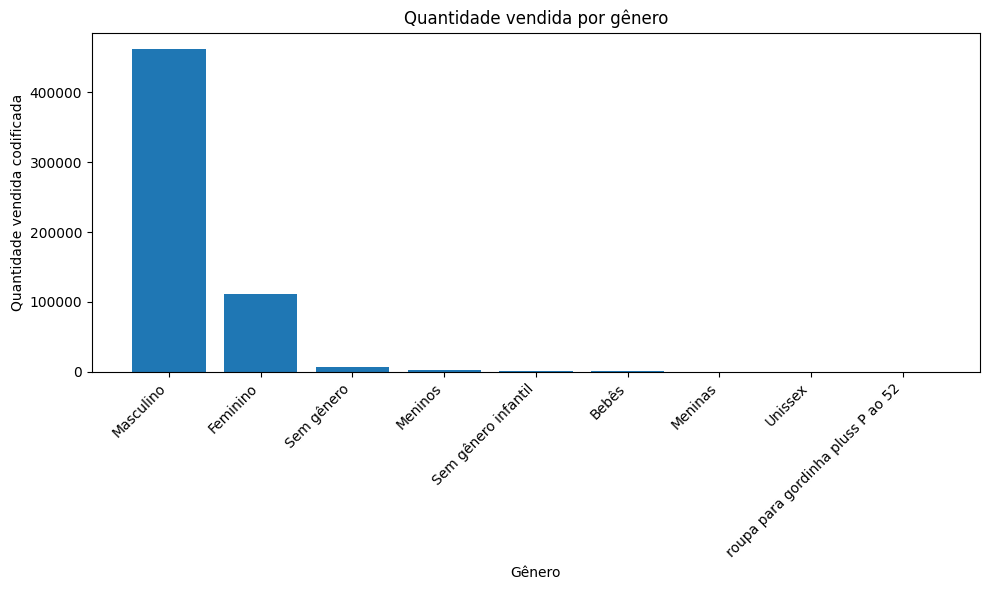

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(vendas_genero['genero'], vendas_genero['qtd_vendidos_cod'])
plt.title('Quantidade vendida por gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade vendida codificada')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('imagens/grafico_vendas_genero.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Relação entre preço e quantidade vendida

O gráfico de dispersão permite observar se produtos com determinados preços apresentam maior ou menor quantidade vendida.

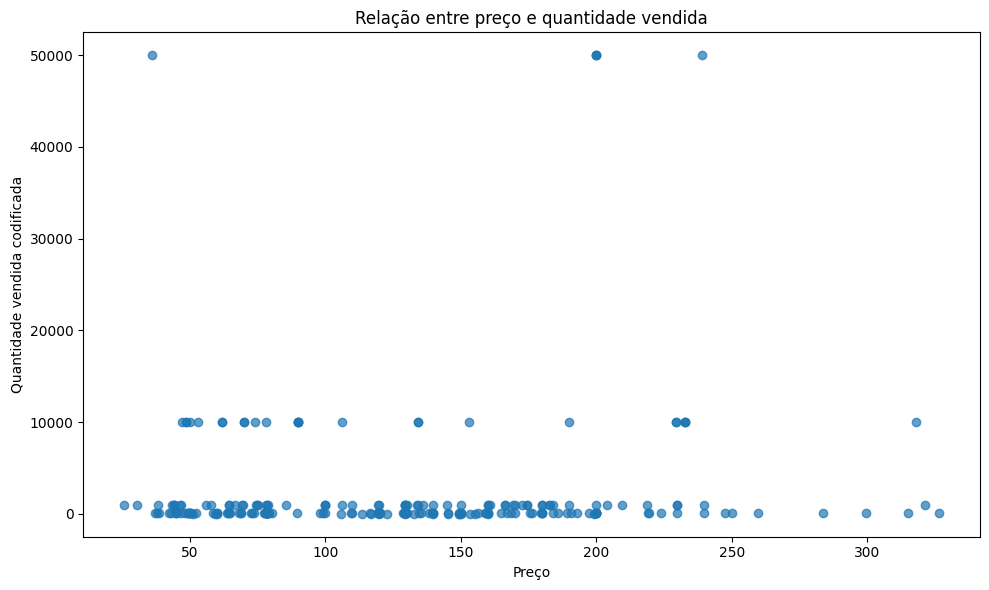

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df['preco'], df['qtd_vendidos_cod'], alpha=0.7)
plt.title('Relação entre preço e quantidade vendida')
plt.xlabel('Preço')
plt.ylabel('Quantidade vendida codificada')
plt.tight_layout()
plt.savefig('imagens/grafico_preco_vendas.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Relação entre desconto e quantidade vendida

Esta análise ajuda a verificar se descontos maiores estão associados a maior volume de vendas.

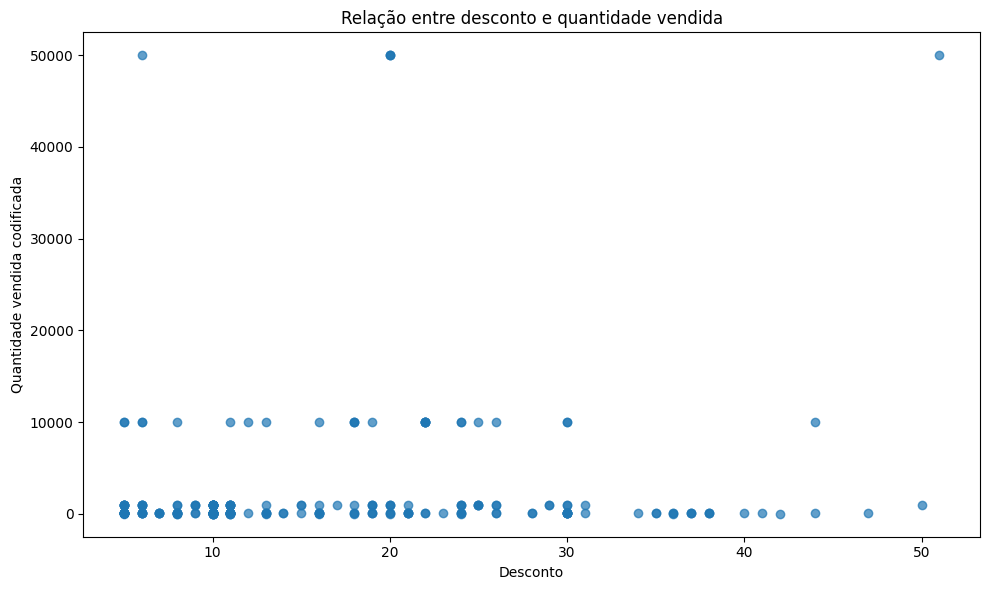

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['desconto'], df['qtd_vendidos_cod'], alpha=0.7)
plt.title('Relação entre desconto e quantidade vendida')
plt.xlabel('Desconto')
plt.ylabel('Quantidade vendida codificada')
plt.tight_layout()
plt.savefig('imagens/grafico_desconto_vendas.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Relação entre avaliações e quantidade vendida

Esta análise verifica se produtos com mais avaliações tendem a apresentar maior quantidade vendida.

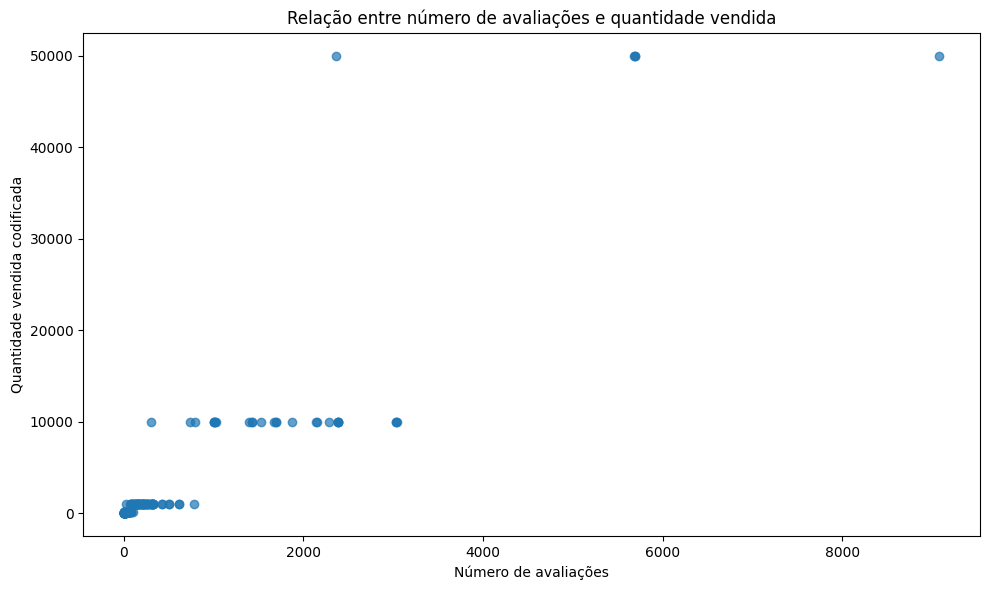

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df['n_avaliacoes'], df['qtd_vendidos_cod'], alpha=0.7)
plt.title('Relação entre número de avaliações e quantidade vendida')
plt.xlabel('Número de avaliações')
plt.ylabel('Quantidade vendida codificada')
plt.tight_layout()
plt.savefig('imagens/grafico_avaliacoes_vendas.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Matriz de correlação

A matriz de correlação ajuda a identificar quais variáveis numéricas possuem maior relação com a quantidade vendida.

Valores próximos de 1 indicam correlação positiva forte. Valores próximos de -1 indicam correlação negativa forte. Valores próximos de 0 indicam baixa relação linear.

In [22]:
correlacao = df.select_dtypes(include='number').corr()

correlacoes_com_vendas = (
    correlacao['qtd_vendidos_cod']
    .sort_values(ascending=False)
    .reset_index()
)

correlacoes_com_vendas.columns = ['variavel', 'correlacao_com_qtd_vendidos_cod']
correlacoes_com_vendas

,variavel,correlacao_com_qtd_vendidos_cod
0,qtd_vendidos_cod,1.000000
1,n_avaliacoes,0.904656
2,n_avaliacoes_minmax,0.904656
3,marca_cod,0.202322
4,desconto,0.122993
5,desconto_minmax,0.122993
6,preco_minmax,0.095143
7,preco,0.095143
8,nota_minmax,0.090688
9,nota,0.090688


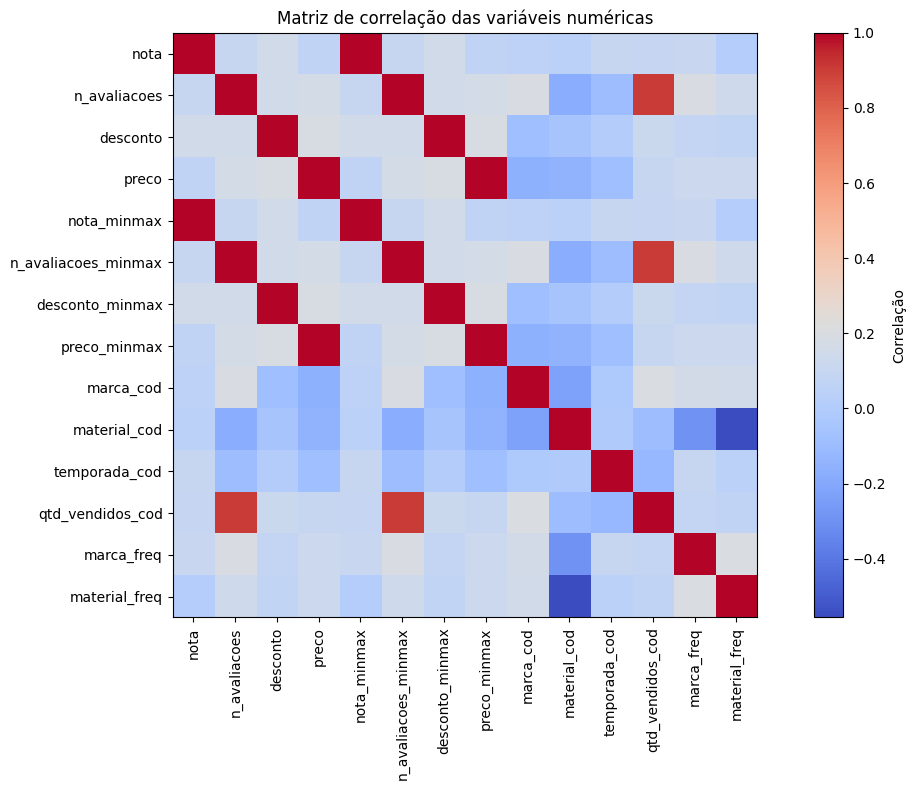

In [23]:
plt.figure(figsize=(12, 8))
plt.imshow(correlacao, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlação')
plt.xticks(range(len(correlacao.columns)), correlacao.columns, rotation=90)
plt.yticks(range(len(correlacao.columns)), correlacao.columns)
plt.title('Matriz de correlação das variáveis numéricas')
plt.tight_layout()
plt.savefig('imagens/mapa_calor_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Geração de arquivos para a entrega

Nesta etapa, exportamos a base tratada e os resultados consolidados para uso no Looker Studio e no GitHub.

In [24]:
# Exportando a base tratada na raiz e na pasta resultados
# O encoding utf-8-sig facilita a abertura correta no Excel e no Google Planilhas.
df.to_csv('base_tratada.csv', index=False, encoding='utf-8-sig')
df.to_csv('resultados/base_tratada.csv', index=False, encoding='utf-8-sig')

# Exportando tabelas agregadas
vendas_marca.to_csv('resultados/vendas_por_marca.csv', index=False, encoding='utf-8-sig')
vendas_material.to_csv('resultados/vendas_por_material.csv', index=False, encoding='utf-8-sig')
vendas_temporada.to_csv('resultados/vendas_por_temporada.csv', index=False, encoding='utf-8-sig')
vendas_genero.to_csv('resultados/vendas_por_genero.csv', index=False, encoding='utf-8-sig')
correlacoes_com_vendas.to_csv('resultados/correlacoes_com_vendas.csv', index=False, encoding='utf-8-sig')

print('Arquivos exportados com sucesso.')

Arquivos exportados com sucesso.


## 16. Relatório de insights

Com base na análise exploratória, foram gerados os principais insights do projeto.

In [25]:
# Valores usados para compor os insights de forma automática
top_marca = vendas_marca.iloc[0]['marca']
top_material = vendas_material.iloc[0]['material']
top_temporada = vendas_temporada.iloc[0]['temporada']

corr_avaliacoes = df['n_avaliacoes'].corr(df['qtd_vendidos_cod'])
corr_desconto = df['desconto'].corr(df['qtd_vendidos_cod'])
corr_preco = df['preco'].corr(df['qtd_vendidos_cod'])
corr_nota = df['nota'].corr(df['qtd_vendidos_cod'])

insights = pd.DataFrame({
    'Insight': [
        f'A marca com maior quantidade vendida codificada foi {top_marca}.',
        f'O material com maior quantidade vendida codificada foi {top_material}.',
        f'A temporada com maior quantidade vendida codificada foi {top_temporada}.',
        f'O número de avaliações apresentou correlação de {corr_avaliacoes:.2f} com a quantidade vendida codificada.',
        f'O desconto apresentou correlação de {corr_desconto:.2f} com a quantidade vendida codificada.',
        f'O preço apresentou correlação de {corr_preco:.2f} com a quantidade vendida codificada.',
        f'A nota apresentou correlação de {corr_nota:.2f} com a quantidade vendida codificada.'
    ],
    'Interpretação': [
        'Essa marca pode ser priorizada em campanhas, análise de estoque e ações comerciais.',
        'Esse material pode indicar preferência dos consumidores e deve ser observado no planejamento de produtos.',
        'A sazonalidade pode ajudar no planejamento de campanhas e reposição de estoque.',
        'Produtos com mais avaliações tendem a apresentar maior volume de vendas, sugerindo influência da prova social.',
        'A relação entre desconto e vendas deve ser avaliada com cuidado antes de aplicar promoções generalizadas.',
        'A relação entre preço e vendas ajuda a identificar faixas de preço mais competitivas.',
        'A nota pode influenciar a percepção de qualidade, mas deve ser analisada junto com avaliações e vendas.'
    ],
    'Sugestão de ação': [
        'Dar destaque aos produtos das marcas com melhor desempenho.',
        'Monitorar materiais com maior demanda e priorizá-los no estoque.',
        'Planejar campanhas conforme as temporadas com maior desempenho.',
        'Estimular avaliações de clientes e destacar produtos bem avaliados.',
        'Testar descontos por categoria e medir o impacto real nas vendas.',
        'Avaliar precificação por faixa de produto e categoria.',
        'Combinar análise de nota, reviews e volume de vendas para decisões comerciais.'
    ]
})

insights.to_csv('resultados/insights_ecommerce.csv', index=False, encoding='utf-8-sig')
insights

,Insight,Interpretação,Sugestão de ação
0,A marca com maior quantidade vendida codificad...,"Essa marca pode ser priorizada em campanhas, a...",Dar destaque aos produtos das marcas com melho...
1,O material com maior quantidade vendida codifi...,Esse material pode indicar preferência dos con...,Monitorar materiais com maior demanda e priori...
2,A temporada com maior quantidade vendida codif...,A sazonalidade pode ajudar no planejamento de ...,Planejar campanhas conforme as temporadas com ...
3,O número de avaliações apresentou correlação d...,Produtos com mais avaliações tendem a apresent...,Estimular avaliações de clientes e destacar pr...
4,O desconto apresentou correlação de 0.12 com a...,A relação entre desconto e vendas deve ser ava...,Testar descontos por categoria e medir o impac...
5,O preço apresentou correlação de 0.10 com a qu...,A relação entre preço e vendas ajuda a identif...,Avaliar precificação por faixa de produto e ca...
6,A nota apresentou correlação de 0.09 com a qua...,A nota pode influenciar a percepção de qualida...,"Combinar análise de nota, reviews e volume de ..."


## 17. Conclusão

A análise exploratória mostrou que a quantidade vendida em um e-commerce pode estar relacionada a diferentes fatores, como número de avaliações, marca, material, preço, desconto e temporada.

A variável `n_avaliacoes` apresentou forte associação com `qtd_vendidos_cod`, indicando que produtos com maior número de avaliações também tendem a apresentar maior volume de vendas. Isso sugere que avaliações podem funcionar como um indicador de confiança, popularidade e prova social.

Além disso, a análise por marca, material, gênero e temporada permite identificar grupos com maior desempenho comercial. Essas informações podem apoiar decisões sobre campanhas, estoque, precificação, descontos e priorização de produtos.

## Recomendações

- Destacar produtos com alto número de avaliações.
- Monitorar marcas e materiais com maior quantidade vendida.
- Avaliar descontos com base em resultado real de vendas.
- Usar o dashboard no Looker Studio para acompanhar os principais indicadores.
- Utilizar a base tratada `base_tratada.csv` para criar visualizações e filtros interativos.

## 18. Arquivos gerados

Após executar este notebook, os seguintes arquivos serão criados:

```text
base_tratada.csv
resultados/base_tratada.csv
resultados/vendas_por_marca.csv
resultados/vendas_por_material.csv
resultados/vendas_por_temporada.csv
resultados/vendas_por_genero.csv
resultados/correlacoes_com_vendas.csv
resultados/insights_ecommerce.csv
imagens/histograma_precos.png
imagens/grafico_vendas_marca.png
imagens/grafico_vendas_material.png
imagens/grafico_vendas_temporada.png
imagens/grafico_vendas_genero.png
imagens/grafico_preco_vendas.png
imagens/grafico_desconto_vendas.png
imagens/grafico_avaliacoes_vendas.png
imagens/mapa_calor_correlacao.png
```

O arquivo `base_tratada.csv` pode ser importado no Google Planilhas e conectado ao Looker Studio para criação do dashboard final.